#### Recurrent Neural Networks (RNNs)

A Recurrent Neural Network (RNN) is a class of artificial neural networks where the connections between nodes form a directed cycle. This structure creates an internal, recursive feedback loop that allows the network to exhibit temporal dynamic behavior.

Unlike traditional Feedforward networks, which map an input $X$ directly to an output $Y$ in isolation, an RNN treats its hidden state as a "memory" that is recursively updated at each time step.

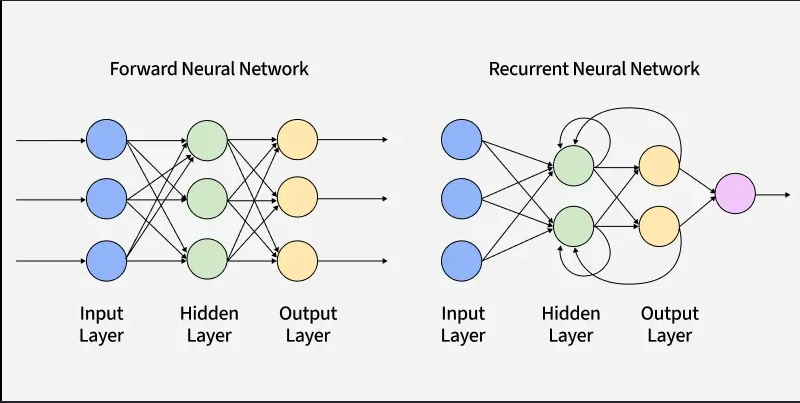

#### Why Do We Use RNNs?

We use RNNs whenever the data is a sequence where the order of elements carries meaning. They are the foundation for tasks like:

 Natural Language Processing (NLP): Text generation, sentiment analysis, machine translation.

 Speech Recognition: Converting audio sequences into text.

 Time Series Analysis: Predicting stock prices, weather forecasting, or sales trends.

 Sequence Prediction: DNA sequence analysis.

### The Math Behind an RNN 

At each time step $t$, the RNN takes two inputs:

The current input data: $X_t$

The hidden state from the previous step: $H_{t-1}$ (This is the "memory")

It then performs two main calculations:

1. Updating the Hidden State (Memory):
The new hidden state $H_t$ is calculated by combining the current input and the previous hidden state, usually passed through an activation function like tanh or ReLU to introduce non-linearity.

$$H_t = \text{tanh}(W_{hx} \cdot X_t + W_{hh} \cdot H_{t-1} + b_h)$$

$W_{hx}$: The weights for the current input.

$W_{hh}$: The weights for the previous hidden state (the "recurrent" weights).

$b_h$: The bias term.

2. Calculating the Output:
The output at the current time step, $Y_t$, is calculated using the newly updated hidden state.

$$Y_t = \text{activation}(W_{yh} \cdot H_t + b_y)$$

$W_{yh}$: The weights connecting the hidden state to the output.

$b_y$: The bias for the output.

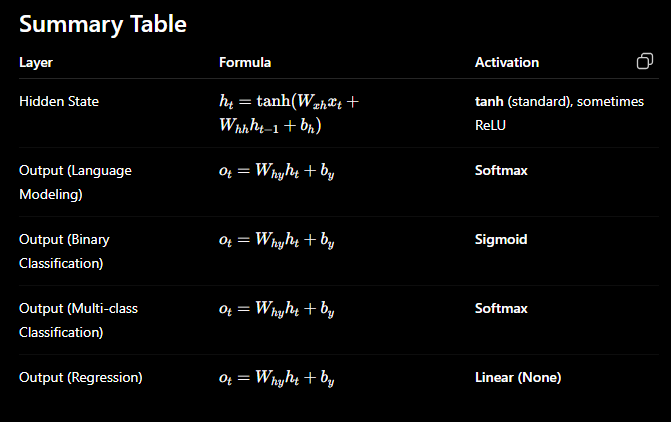

Crucial Concept: Shared Weights
Unlike traditional deep networks where every layer has different weights, a standard RNN shares the same weight matrices ($W_{hx}, W_{hh}, W_{yh}$) across every single time step in the sequence. This drastically reduces the number of parameters the network needs to learn.

##### Advantages of RNNs

Handling Sequential Data: They are naturally designed to process inputs of varying lengths (e.g., a 3-word sentence vs. a 20-word sentence).

Memory of Past Inputs: Their hidden state allows them to capture historical context, making them effective for tasks where previous data points influence future ones.

Parameter Sharing: By reusing the same weights across all time steps, the model size is kept relatively small, which helps prevent overfitting on smaller datasets.

##### Disadvantages and Limitations of RNNs

While groundbreaking, standard ("Vanilla") RNNs suffer from significant mathematical flaws during training, primarily due to the way they use Backpropagation Through Time (BPTT) to calculate errors.

1. The Vanishing Gradient Problem (The biggest issue)
When an RNN processes a very long sequence, the gradients (the error signals used to update weights) must be multiplied repeatedly as they travel backward through time. If the recurrent weights ($W_{hh}$) are less than 1, these repeated multiplications cause the gradients to shrink exponentially until they "vanish" to zero.

Result: The network stops learning. It develops "short-term memory loss" and completely forgets information from the beginning of a long sequence.

2. The Exploding Gradient Problem
Conversely, if the recurrent weights are greater than 1, the repeated multiplication causes the gradients to grow exponentially to massive numbers.

Result: The algorithm becomes unstable, and the weights update violently, causing the model to crash or output NaN (Not a Number).

3. Slow Training Computation
Because the hidden state $H_t$ depends strictly on the previous state $H_{t-1}$, RNNs must process sequences sequentially. They cannot be parallelized easily across modern GPUs, making them very slow to train on large datasets compared to newer architectures.

##### The Modern Solution: LSTMs and Transformers

Because of the severe limitations of standard RNNs (especially the vanishing gradient), they are rarely used in modern, complex deep learning. They have largely been replaced by:

LSTMs (Long Short-Term Memory) & GRUs: These are advanced variations of RNNs that add complex mathematical "gates" (Input, Forget, and Output gates) to control exactly what information is remembered or thrown away, effectively solving the vanishing gradient problem.

Transformers: The architecture behind modern LLMs (like ChatGPT). Transformers abandon recurrence entirely in favor of an "Attention" mechanism, allowing them to process entire sequences simultaneously (highly parallelizable) and retain perfect long-term context.

In [17]:
import tensorflow as tf
from keras import Sequential
from keras.datasets import imdb
from keras.layers import Dense,SimpleRNN,Embedding,Flatten
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences
import numpy as np

Sequential data is information that follows a specific order, where every data point is dependent on the context provided by the preceding data points. 

#### 1. Key Types of Sequential Data
*   **Time-Series Data:** Observations indexed by time (e.g., Stock prices, daily temperature readings, CPU load over time).
*   **Natural Language (Text):** Sentences are sequences of words. The meaning of the word "bank" depends on whether the preceding words are "river" or "money."
*   **Audio/Speech:** Audio files are sequences of sound waves (samples) over time. To recognize a syllable, the model must hear the specific sequence of frequencies.
*   **Video:** Video is a sequence of image frames. Movement is only perceptible because the model can track how objects change position across sequential frames.
*   **Biological Sequences:** DNA (A, C, G, T) and protein sequences are ordered chains; the order determines the biological function.

#### 2. Why "Order" Matters (The Challenge)
Standard Feedforward Neural Networks (MLPs) are **stateless**. They look at input $X$ and map it to output $Y$. If you gave an MLP a sentence as an input, it would be forced to treat the first word and the last word as independent features, losing the grammatical and semantic relationship between them.

Sequential models, like **RNNs, LSTMs, and Transformers**, are **stateful**. They process data one step at a time (or use Attention mechanisms) to maintain "context" or "memory" of what came before.

#### 3. Comparison: Static Data vs. Sequential Data

| Feature | Static/Tabular Data | Sequential Data |
| :--- | :--- | :--- |
| **Dependency** | Independent (I.I.D.) | Dependent (Temporal) |
| **Order** | Order doesn't matter | Order is critical |
| **Example** | Age, Income, Gender | Voice, Stock Price, DNA |
| **Primary Challenge** | Relationships between features | Relationships over time/distance |
| **Model Type** | Dense/Feedforward NNs | RNN, LSTM, Transformer |


### Why ANNs struggle with Text Classification

While a basic Feedforward Neural Network (ANN) can technically perform text classification, it suffers from four fundamental architectural limitations.

#### 1. The "Word Salad" Problem (Lack of Sequential Awareness)
Standard ANNs use a **"Bag-of-Words"** approach. They process inputs as a single, static vector. They cannot differentiate between:
*   "The dog bit the man."
*   "The man bit the dog."

Because an ANN feeds all input features into the first hidden layer simultaneously, it loses the **order** of the words. It knows *that* the words "dog," "bit," and "man" appear in the sentence, but it doesn't know the sequence. In language, the sequence is the definition of meaning.

#### 2. The Fixed-Input Constraint
ANNs require a **fixed-size input layer**. If your input layer has 10,000 neurons (representing your vocabulary), every single sentence you process must be exactly 10,000 numbers long.
*   To handle variable-length sentences, you are forced to use **Padding** (adding zeros to the end of short sentences) or **Truncating** (cutting off long sentences). 
*   This introduces unnecessary noise and computational waste, as a 5-word sentence and a 500-word sentence are both forced into the same rigid format.

#### 3. The "Context" Blind Spot
Human language relies on **long-range dependencies**. Consider this sentence:
> "The **cat**, which was hiding under the sofa for three hours, finally **ate**."

To understand who performed the action "ate," the model must remember the subject ("cat") across several intervening words. A standard ANN has no memory. It processes the input as one big snapshot. It cannot "carry forward" the state of the subject to connect it to the verb later in the sentence. 

#### 4. High Dimensionality and Sparsity
When using techniques like One-Hot Encoding for an ANN:
*   **Dimensionality:** If you have 50,000 unique words in your vocabulary, every single input sentence becomes a 50,000-dimensional vector. 
*   **Sparsity:** In any given sentence, 99.9% of that vector will be zeros.
*   **The Problem:** ANNs rely on dense matrix multiplications. Processing massive, mostly-empty (sparse) vectors is mathematically inefficient and leads to "parameter explosion," where your model needs millions of weights just to learn basic vocabulary, making it extremely prone to overfitting.

## Tokenization 

In [2]:
docs = ['go india',
		'india india',
		'hip hip hurray',
		'jeetega bhai jeetega india jeetega',
		'bharat mata ki jai',
		'kohli kohli',
		'sachin sachin',
		'dhoni dhoni',
		'modi ji ki jai',
		'inquilab zindabad']

In [ ]:
tokenizer = Tokenizer(oov_token="<nothing>")
tokenizer.fit_on_texts(docs)

In [4]:
tokenizer.word_index

{'<nothing>': 1,
 'india': 2,
 'jeetega': 3,
 'hip': 4,
 'ki': 5,
 'jai': 6,
 'kohli': 7,
 'sachin': 8,
 'dhoni': 9,
 'go': 10,
 'hurray': 11,
 'bhai': 12,
 'bharat': 13,
 'mata': 14,
 'modi': 15,
 'ji': 16,
 'inquilab': 17,
 'zindabad': 18}

In [5]:
tokenizer.word_counts

OrderedDict([('go', 1),
             ('india', 4),
             ('hip', 2),
             ('hurray', 1),
             ('jeetega', 3),
             ('bhai', 1),
             ('bharat', 1),
             ('mata', 1),
             ('ki', 2),
             ('jai', 2),
             ('kohli', 2),
             ('sachin', 2),
             ('dhoni', 2),
             ('modi', 1),
             ('ji', 1),
             ('inquilab', 1),
             ('zindabad', 1)])

In [6]:
tokenizer.word_counts

OrderedDict([('go', 1),
             ('india', 4),
             ('hip', 2),
             ('hurray', 1),
             ('jeetega', 3),
             ('bhai', 1),
             ('bharat', 1),
             ('mata', 1),
             ('ki', 2),
             ('jai', 2),
             ('kohli', 2),
             ('sachin', 2),
             ('dhoni', 2),
             ('modi', 1),
             ('ji', 1),
             ('inquilab', 1),
             ('zindabad', 1)])

In [20]:
sequences_ = tokenizer.texts_to_sequences(docs)
sequences_

[[10, 2],
 [2, 2],
 [4, 4, 11],
 [3, 12, 3, 2, 3],
 [13, 14, 5, 6],
 [7, 7],
 [8, 8],
 [9, 9],
 [15, 16, 5, 6],
 [17, 18]]

In [22]:
sequences_ = pad_sequences(sequences_,padding="post")
sequences_

array([[10,  2,  0,  0,  0],
       [ 2,  2,  0,  0,  0],
       [ 4,  4, 11,  0,  0],
       [ 3, 12,  3,  2,  3],
       [13, 14,  5,  6,  0],
       [ 7,  7,  0,  0,  0],
       [ 8,  8,  0,  0,  0],
       [ 9,  9,  0,  0,  0],
       [15, 16,  5,  6,  0],
       [17, 18,  0,  0,  0]])

### RNN Sentiment Analysis

In [30]:
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

In [36]:
X_train = pad_sequences(X_train,padding='post',maxlen=50)
X_test = pad_sequences(X_test,padding='post',maxlen=50)

In [37]:
model = Sequential([
    Embedding(
        input_dim=10000,      # Vocabulary size of IMDB dataset
        output_dim=32,        # Embedding dimension
        input_length=50       # Length after padding
    ),

    SimpleRNN(
        units=32,
        activation="tanh"
    ),

    Dense(1, activation="sigmoid")
])

In [43]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 50, 32)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 966,341 (3.69 MB)

 Trainable params: 322,113 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 644,228 (2.46 MB)

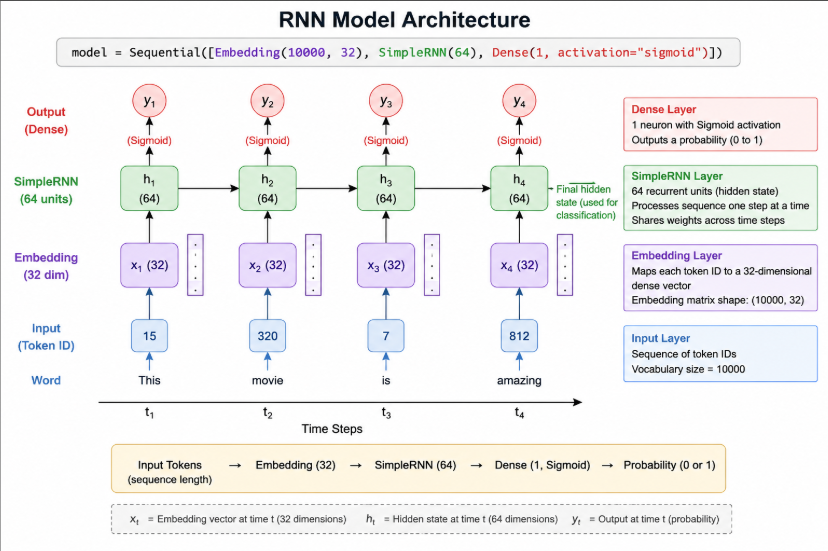

The diagram shows a general RNN architecture where each time step can produce an output. In sentiment analysis, we need one label for the entire sequence, so we use only the final hidden state (return_sequences=False) and pass it to a Dense layer for classification.

the outputs y₁, y₂, y₃ are never generated as separate outputs.[Only final output (from h₄)]

In [38]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [39]:
model.fit(X_train,y_train,epochs=5,validation_data=(X_test,y_test))

Epoch 1/5


782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 31ms/step - accuracy: 0.6966 - loss: 0.5518 - val_accuracy: 0.7936 - val_loss: 0.4427
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 32ms/step - accuracy: 0.8520 - loss: 0.3491 - val_accuracy: 0.7980 - val_loss: 0.4362
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 31ms/step - accuracy: 0.9186 - loss: 0.2107 - val_accuracy: 0.7940 - val_loss: 0.5462
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 44s 35ms/step - accuracy: 0.9720 - loss: 0.0879 - val_accuracy: 0.7602 - val_loss: 0.6822
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/step - accuracy: 0.9902 - loss: 0.0343 - val_accuracy: 0.7678 - val_loss: 0.8373


In [40]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7678 - loss: 0.8373
Test Loss : 0.8372562527656555
Test Accuracy : 0.767799973487854


In [41]:
prediction = model.predict(X_test[:5])
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 720ms/step
[[0.00518673]
 [0.9994727 ]
 [0.3773132 ]
 [0.9158383 ]
 [0.99729455]]


In [42]:
for p in prediction:
    if p >= 0.5:
        print("Positive")
    else:
        print("Negative")

Negative
Positive
Negative
Positive
Positive
